In [28]:
import time
from pathlib import Path
import pandas as pd
from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score



# 1. Configuración de ruta y arranque de Kedro
start_time = time.time()
project_path = Path.cwd().parent

print("=" * 65)
print(f"🚀 INICIANDO KEDRO DATA CONTEXT | ENTRENAMIENTO BIOMÉDICO")
print("=" * 65)
print(f"📁 Raíz del Proyecto: {project_path}")

try:
    bootstrap_project(project_path)
    with KedroSession.create(project_path) as session:
        context = session.load_context()
        catalog = context.catalog
    
    # 2. Carga de Artefactos Oficiales del Catálogo
    df = catalog.load("df_nhanes_limpio")
    model = catalog.load("modelo_hipertension")
    
    # 3. Extracción de Metadatos del Modelo (XGBoost)
    # Averiguamos qué variables usó el modelo originalmente
    features_usadas = df.drop(columns=["Riesgo_Hipertension"]).columns.tolist()
    total_hipertensos = int(df["Riesgo_Hipertension"].sum())
    pct_hipertensos = (total_hipertensos / len(df)) * 100
    
    # Calcular tiempo de carga
    elapsed_time = time.time() - start_time

    # 4. TABLERO DE CONTROL PREMIUM (Output visual en consola)
    print("\n📦 " + " CATALOG CONEXIÓN EXITOSA ".center(55, "-"))
    print(f" Status Datasets   :  🟢 Sincronizado con Data Catalog")
    print(f" Tiempo de Carga   :  ⏱️  {elapsed_time:.2f} segundos")
    
    print("\n📊 " + " DIAGNÓSTICO METODOLÓGICO DEL DATASET ".center(55, "-"))
    print(f" 👥 Volumen Total  :  {df.shape[0]:,} pacientes procesados".replace(",", "."))
    print(f" 🧬 Dimensiones    :  {df.shape[1]} columnas clínicas seleccionadas")
    print(f" 🎯 Target Clínico :  Riesgo_Hipertension")
    print(f" 📈 Balanceo       :  {total_hipertensos:,} Positivos ({pct_hipertensos:.1f}%) | {len(df)-total_hipertensos:,} Negativos".replace(",", "."))
    
    print("\n🤖 " + " ESPECIFICACIONES DE ARQUITECTURA AI ".center(55, "-"))
    print(f" 🧠 Core Algorithm :  {type(model).__name__} (Machine Learning)")
    print(f" 🛠️  Estimadores    :  {model.get_params().get('n_estimators', '100')} árboles de decisión integrados")
    print(f" 🔍 Input Features :  {features_usadas}")
    print("=" * 65)
    print("💎 SISTEMA LISTO PARA PRODUCCIÓN Y VISUALIZACIÓN")
    print("=" * 65)

except Exception as e:
    print(f"\n❌ ERROR CRÍTICO AL CONECTAR CON KEDRO:\n{str(e)}")

🚀 INICIANDO KEDRO DATA CONTEXT | ENTRENAMIENTO BIOMÉDICO
📁 Raíz del Proyecto: C:\Users\maico\Proyectos\nhanes-pipeline


[06/26/26 11:10:55] INFO     No typed parameter requirements found, returning original   ]8;id=182597;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=182598;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=182603;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=182604;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Loading data from df_nhanes_limpio (CSVDataset)...                ]8;id=182609;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=182610;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from modelo_hipertension (PickleDataset)...          ]8;id=182615;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=182616;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\


📦 --------------- CATALOG CONEXIÓN EXITOSA --------------
 Status Datasets   :  🟢 Sincronizado con Data Catalog
 Tiempo de Carga   :  ⏱️  1.35 segundos

📊 --------- DIAGNÓSTICO METODOLÓGICO DEL DATASET --------
 👥 Volumen Total  :  27.375 pacientes procesados
 🧬 Dimensiones    :  9 columnas clínicas seleccionadas
 🎯 Target Clínico :  Riesgo_Hipertension
 📈 Balanceo       :  8.862 Positivos (32.4%) | 18.513 Negativos

🤖 --------- ESPECIFICACIONES DE ARQUITECTURA AI ---------
 🧠 Core Algorithm :  XGBClassifier (Machine Learning)
 🛠️  Estimadores    :  100 árboles de decisión integrados
 🔍 Input Features :  ['Edad', 'Genero', 'Peso_kg', 'Estatura_cm', 'IMC', 'Cintura_cm', 'Colesterol_Total', 'Fumador']
💎 SISTEMA LISTO PARA PRODUCCIÓN Y VISUALIZACIÓN


In [29]:
import numpy as np
import pandas as pd

# 1. Filtrar las columnas numéricas excluyendo la variable objetivo
columnas_numericas = df.select_dtypes(include=[np.number]).columns
variables_clinicas = [col for col in columnas_numericas if col != 'Riesgo_Hipertension']

# Generar el resumen estadístico original
resumen = df[variables_clinicas].describe().T

# Renombrar las columnas estadísticas para que se vean más profesionales
resumen = resumen.rename(columns={
    'count': 'Nº Registros',
    'mean': 'Media',
    'std': 'Desv. Est.',
    'min': 'Mínimo',
    '25%': 'Perc. 25',
    '50%': 'Mediana (50%)',
    '75%': 'Perc. 75',
    'max': 'Máximo'
})

# 2. Aplicar Diseño Ejecutivo Minimalista de Alta Legibilidad
resumen_premium = resumen.style\
    .format("{:,.2f}")\
    .set_properties(**{
        'font-family': 'Segoe UI, Sans-serif',
        'font-size': '13px',
        'text-align': 'center',
        'padding': '10px 18px',
        'background-color': '#FFFFFF',
        'color': '#2C3E50'
    })\
    .set_table_styles([
        # Cabecera sofisticada gris claro con línea base azul marino
        {'selector': 'th', 'props': [
            ('background-color', '#F8F9F9'), 
            ('color', '#1A5276'), 
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('border-bottom', '2px solid #1A5276'),
            ('padding', '10px 18px'),
            ('text-align', 'center')
        ]},
        # Líneas divisorias delgadas horizontales (estilo artículo académico)
        {'selector': 'td', 'props': [('border-bottom', '1px solid #E5E7E9')]},
        # Resaltado sutil al pasar el mouse por encima
        {'selector': 'tr:hover', 'props': [('background-color', '#F4F6F7')]}
    ])

print("📋 PERFIL ESTADÍSTICO DE LAS VARIABLES CLÍNICAS (NHANES) - RESUMEN EJECUTIVO:")
resumen_premium

📋 PERFIL ESTADÍSTICO DE LAS VARIABLES CLÍNICAS (NHANES) - RESUMEN EJECUTIVO:


,Nº Registros,Media,Desv. Est.,Mínimo,Perc. 25,Mediana (50%),Perc. 75,Máximo
Edad,"27,375.00",39.47,22.28,8.00,18.00,38.00,59.00,80.00
Genero,"27,375.00",1.51,0.50,1.00,1.00,2.00,2.00,2.00
Peso_kg,"27,375.00",74.42,24.59,16.90,58.50,72.60,88.30,222.60
Estatura_cm,"27,375.00",163.66,12.82,109.50,156.40,164.50,172.50,204.50
IMC,"27,375.00",27.31,7.39,12.30,22.20,26.40,31.20,84.40
Cintura_cm,"27,375.00",93.07,18.83,46.30,79.80,92.60,104.80,177.90
Colesterol_Total,"27,375.00",181.21,39.68,59.00,155.00,177.00,203.00,813.00
Fumador,"27,375.00",1.69,0.49,1.00,1.00,2.00,2.00,9.00


In [37]:
# --- BLOQUE INTERMEDIO: GENERACIÓN DE PREDICCIONES CLÍNICAS ---

# 1. Separar la condición real (Target) y las variables predictoras (Features)
y_true = df["Riesgo_Hipertension"]
X_features = df.drop(columns=["Riesgo_Hipertension"])

# 2. Obtener las probabilidades de riesgo que calcula el XGBoost
# ( predict_proba devuelve [prob_sano, prob_hipertenso], nos quedamos con la segunda )
probabilidades = model.predict_proba(X_features)[:, 1]

# 3. Aplicar tu Umbral Clínico Optimizado de 0.6
y_pred = (probabilidades >= 0.6).astype(int)

print(" Variables 'y_true' e 'y_pred' generadas exitosamente con el umbral 0.6.")
print(f"Total de pacientes evaluados para la matriz: {len(y_true):,}")

X = X_features
y_probs = probabilidades

 Variables 'y_true' e 'y_pred' generadas exitosamente con el umbral 0.6.
Total de pacientes evaluados para la matriz: 27,375


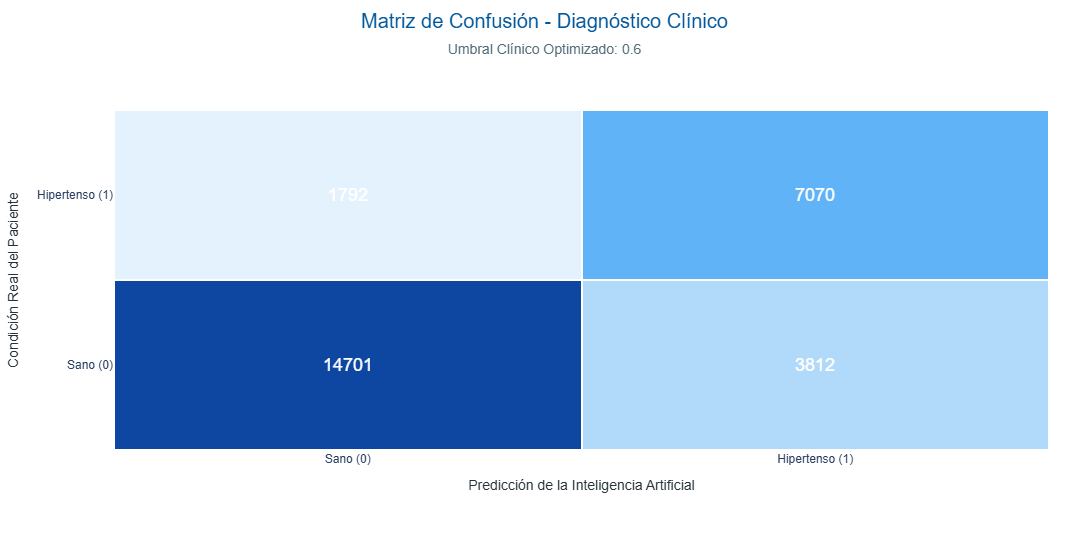

In [31]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import confusion_matrix

# --- 1. Prepare Data ---

# Ensure these variables (y_true, y_pred) exist from your previous cells
cm = confusion_matrix(y_true, y_pred)

# Define labels for clarity
x_labels = ['Sano (0)', 'Hipertenso (1)']
y_labels = ['Sano (0)', 'Hipertenso (1)']

# Total patients for percentages
total_samples = np.sum(cm)

# --- 2. Define Detailed Tooltips ---

# Create specific hover text for each cell
# cm[y, x] where y is true, x is predicted
annotations_tooltips = [
    [f"<b>{cm[0, 0]}</b> Pacientes Sanos<br>correctamente clasificados", # True Negative
     f"<b>{cm[0, 1]}</b> Pacientes Sanos<br>clasificados como Riesgo (Falso Alarma)"], # False Positive
    [f"<b>{cm[1, 0]}</b> Pacientes Hipertensos<br>clasificados como Sanos (Fallo Clínico)", # False Negative
     f"<b>{cm[1, 1]}</b> Pacientes Hipertensos<br>correctamente identificados"] # True Positive
]

# --- 3. Create the Interactive Plotly Heatmap ---

fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=x_labels,
    y=y_labels,
    colorscale=[
        [0, "#E3F2FD"],  # Very light blue (low values)
        [0.5, "#42A5F5"], # Mid blue
        [1, "#0D47A1"]   # Dark blue (high values)
    ],
    xgap=2, # Creates subtle grid lines
    ygap=2,
    showscale=False, # Hide the color bar for a clean look
    text=cm, # The raw numbers to display in the cell
    texttemplate="%{text}", # Template for showing raw numbers
    textfont={"size": 18, "color": "white", "family": "Arial, Bold"}, # Styled raw numbers
    hoverinfo='text', # Display our custom tooltips on hover
    hovertext=annotations_tooltips # The tooltip list
))

# --- 4. Style the Interactive Layout ---

fig.update_layout(
    title={
        'text': "Matriz de Confusión - Diagnóstico Clínico<br><span style='font-size:14px; color:#546E7A'>Umbral Clínico Optimizado: 0.6</span>",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20, 'color': '#01579B', 'family': 'Arial, Bold'}
    },
    xaxis_title={'text': 'Predicción de la Inteligencia Artificial', 'font': {'size': 14, 'color': '#263238', 'family': 'Arial, Bold'}},
    yaxis_title={'text': 'Condición Real del Paciente', 'font': {'size': 14, 'color': '#263238', 'family': 'Arial, Bold'}},
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis={'tickfont': {'size': 12, 'family': 'Arial'}, 'side': 'bottom'},
    yaxis={'tickfont': {'size': 12, 'family': 'Arial'}},
    width=600, # Presentation size
    height=550,
    margin=dict(l=100, r=40, b=100, t=110), # Adjusted margins for titles
)

# --- 5. Fix Axis Tick Positioning ---

# This handles categorical axes alignment in Plotly
fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=x_labels
)
fig.update_yaxes(
    tickvals=[0, 1],
    ticktext=y_labels,
    automargin=True
)

# --- 6. Display the Chart ---
fig.show()

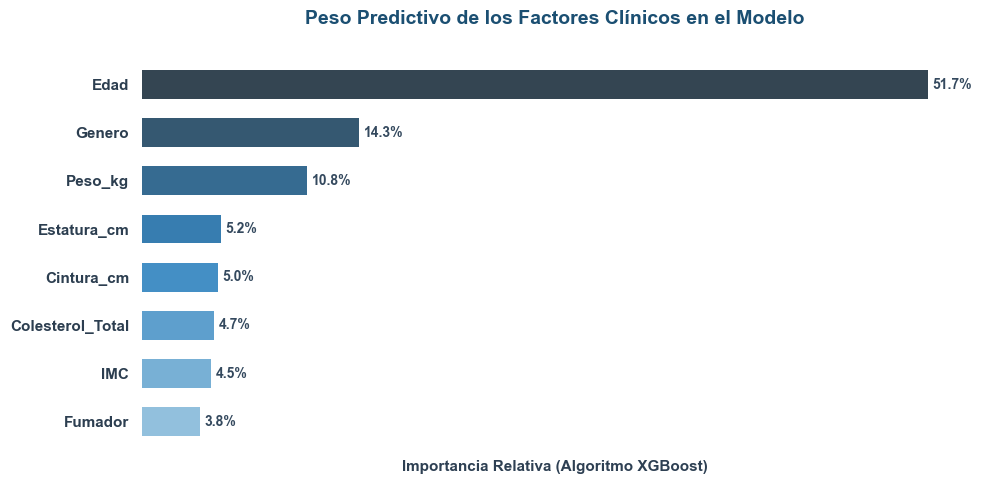

In [32]:
import pandas as pd

# 1. Extraer los pesos directamente de tu modelo XGBoost entrenado
importances = model.feature_importances_
features = X.columns

df_importance = pd.DataFrame({
    'Variable': features, 
    'Importancia': importances
}).sort_values(by='Importancia', ascending=True)

# 2. Configurar lienzo minimalista
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

# Paleta degradada elegante
colors = sns.color_palette("Blues_d", len(df_importance))

# 3. Graficar barras horizontales limpias
bars = plt.barh(df_importance['Variable'], df_importance['Importancia'], 
                color=colors, edgecolor='none', height=0.6)

plt.title('Peso Predictivo de los Factores Clínicos en el Modelo', 
          fontsize=14, fontweight='bold', pad=20, color='#1B4F72')
plt.xlabel('Importancia Relativa (Algoritmo XGBoost)', fontsize=11, fontweight='600', color='#2E4053')

# Remover bordes innecesarios
sns.despine(left=True, bottom=True)

# 4. Añadir etiquetas de porcentaje perfectas al borde de cada barra
for bar in bars:
    width = bar.get_width()
    if width > 0:
        plt.text(width + 0.003, 
                 bar.get_y() + bar.get_height()/2, 
                 f'{width*100:.1f}%', 
                 va='center', ha='left', 
                 fontsize=10, fontweight='bold', color='#34495E')

plt.xticks([]) # Ocultar escala inferior redundante
plt.yticks(fontsize=11, fontweight='600', color='#2C3E50')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report
import pandas as pd

# 1. Generar el reporte de clasificación original
reporte_dict = classification_report(y_true, y_pred, target_names=['Sano', 'Hipertenso'], output_dict=True)
df_reporte = pd.DataFrame(reporte_dict).T

# Limpieza de artefactos: Evitamos que 'accuracy' llene las columnas de precisión/recall
df_reporte.loc['accuracy', ['precision', 'recall']] = None

# Corregimos el total de soporte para la fila de accuracy
df_reporte.loc['accuracy', 'support'] = df_reporte.loc['weighted avg', 'support']

# Renombrar las filas para que tengan nombres elegantes y profesionales
df_reporte = df_reporte.rename(index={
    'Sano': 'Pacientes Sanos (Clase 0)',
    'Hipertenso': 'Pacientes en Riesgo (Clase 1)',
    'accuracy': 'Exactitud General (Accuracy)',
    'macro avg': 'Promedio Macro (Macro Avg)',
    'weighted avg': 'Promedio Ponderado (Weighted Avg)'
})

# 2. Aplicar diseño Ejecutivo Minimalista (Sin bloques de color de fondo)
reporte_ejecutivo = df_reporte.style\
    .format("{:.2f}", subset=['precision', 'recall', 'f1-score'], na_rep="-")\
    .format("{:.0f}", subset=['support'])\
    .set_properties(**{
        'font-family': 'Segoe UI, Sans-serif',
        'font-size': '13px',
        'text-align': 'center',
        'padding': '12px 24px',
        'background-color': '#FFFFFF',
        'color': '#2C3E50'
    })\
    .set_table_styles([
        # Cabecera sofisticada: Fondo gris claro sutil con línea base azul marino
        {'selector': 'th', 'props': [
            ('background-color', '#F8F9F9'), 
            ('color', '#1A5276'), 
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('border-bottom', '2px solid #1A5276'),
            ('padding', '12px 24px'),
            ('text-align', 'center')
        ]},
        # Líneas divisorias horizontales muy delgadas (estilo artículo científico)
        {'selector': 'td', 'props': [('border-bottom', '1px solid #E5E7E9')]},
        # Efecto sutil al pasar el cursor por encima
        {'selector': 'tr:hover', 'props': [('background-color', '#F4F6F7')]}
    ])

print("🏆 EVALUACIÓN DE MÉTRICAS CLÍNICAS - RESUMEN EJECUTIVO:")
reporte_ejecutivo

🏆 EVALUACIÓN DE MÉTRICAS CLÍNICAS - RESUMEN EJECUTIVO:


,precision,recall,f1-score,support
Pacientes Sanos (Clase 0),0.89,0.79,0.84,18513
Pacientes en Riesgo (Clase 1),0.65,0.80,0.72,8862
Exactitud General (Accuracy),-,-,0.80,27375
Promedio Macro (Macro Avg),0.77,0.80,0.78,27375
Promedio Ponderado (Weighted Avg),0.81,0.80,0.80,27375


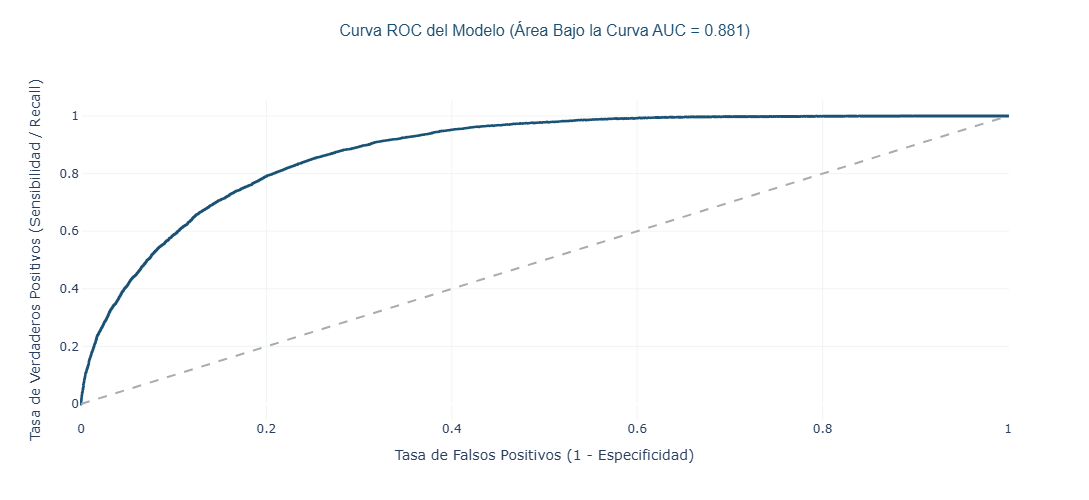

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.express as px

# Calcular tasas
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
auc_score = roc_auc_score(y_true, y_probs)

# Crear DataFrame para Plotly
df_roc = pd.DataFrame({'FPR': fpr, 'TPR': tpr, 'Umbral': thresholds})

fig_roc = px.line(df_roc, x='FPR', y='TPR', hover_data=['Umbral'],
                 title=f"Curva ROC del Modelo (Área Bajo la Curva AUC = {auc_score:.3f})")

# Estilizar línea y layout
fig_roc.update_traces(line=dict(color='#1A5276', width=3))
fig_roc.add_shape(type='line', line=dict(dash='dash', color='#A6ACAF', width=2), x0=0, x1=1, y0=0, y1=1) # Línea aleatoria

fig_roc.update_layout(
    title={'y':0.95, 'x':0.5, 'xanchor': 'center', 'font': {'size': 16, 'color': '#1B4F72', 'family': 'Arial, Bold'}},
    xaxis_title="Tasa de Falsos Positivos (1 - Especificidad)",
    yaxis_title="Tasa de Verdaderos Positivos (Sensibilidad / Recall)",
    plot_bgcolor='white',
    width=700, height=500
)
fig_roc.update_xaxes(showgrid=True, gridcolor='#F2F3F4')
fig_roc.update_yaxes(showgrid=True, gridcolor='#F2F3F4')

fig_roc.show()

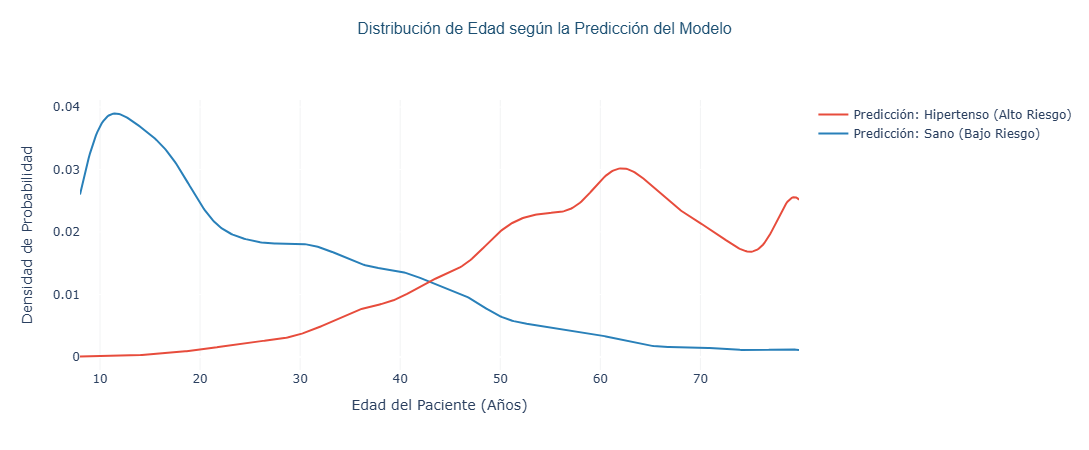

In [35]:
import plotly.figure_factory as ff

# Separar las edades de los que el modelo predice con riesgo vs los que no
edad_sanos = df[y_pred == 0]['Edad']
edad_riesgo = df[y_pred == 1]['Edad']

hist_data = [edad_sanos, edad_riesgo]
group_labels = ['Predicción: Sano (Bajo Riesgo)', 'Predicción: Hipertenso (Alto Riesgo)']
colors = ['#2980B9', '#E74C3C']

# Crear gráfico de distribución de curvas liso (Kernel Density Estimate)
fig_dist = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False, colors=colors)

fig_dist.update_layout(
    title={'text': "Distribución de Edad según la Predicción del Modelo", 'y':0.95, 'x':0.5, 'xanchor': 'center', 'font': {'size': 16, 'color': '#1B4F72', 'family': 'Arial, Bold'}},
    xaxis_title="Edad del Paciente (Años)",
    yaxis_title="Densidad de Probabilidad",
    plot_bgcolor='white',
    width=800, height=450
)
fig_dist.update_xaxes(showgrid=True, gridcolor='#F2F3F4')
fig_dist.show()